In [81]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats

Dataset is found at: https://data.ny.gov/Transportation/MTA-Subway-Hourly-Ridership-2020-2024/wujg-7c2s/about_data

I am performing data analysis to answer a question:
- What factors influence hourly subway ridership
- Predict when a station will experience high ridership (>90th percentile per station)

I intend to visualize the routes that passengers take. I also intend to add weather dataset to enhance predictability.

In [ ]:
url = "https://data.ny.gov/resource/wujg-7c2s.json"

params = {"$limit": 1000000}

print("Requesting data...")
response = requests.get(url, params=params)

if response.status_code == 200:
    data = response.json()
    df = pd.DataFrSame(data)
    print(f"Loaded {len(df)} rows.")
else:
    print("Error fetching data:", response.status_code)

Requesting data...
Loaded 1000000 rows.


In [83]:
df_head = df.head()
df_head

,transit_timestamp,transit_mode,station_complex_id,station_complex,borough,payment_method,fare_class_category,ridership,transfers,latitude,longitude,georeference,:@computed_region_kjdx_g34t,:@computed_region_yamh_8v7k,:@computed_region_wbg7_3whc
0,2021-09-21T08:00:00.000,subway,144,Dyckman St (A),Manhattan,metrocard,Metrocard - Other,23.0,1.0,40.86549,-73.92727,"{'type': 'Point', 'coordinates': [-73.92727, 4...",2095,749,793
1,2021-09-21T13:00:00.000,subway,348,Rockaway Av (3),Brooklyn,metrocard,Metrocard - Students,6.0,2.0,40.662548,-73.90894,"{'type': 'Point', 'coordinates': [-73.90894, 4...",2090,894,890
2,2021-09-21T16:00:00.000,subway,265,"Grand Av-Newtown (M,R)",Queens,metrocard,Metrocard - Students,54.0,11.0,40.737015,-73.87722,"{'type': 'Point', 'coordinates': [-73.87722, 4...",2137,196,843
3,2021-09-21T07:00:00.000,subway,89,Cleveland St (J),Brooklyn,metrocard,Metrocard - Seniors & Disability,5.0,0.0,40.679947,-73.884636,"{'type': 'Point', 'coordinates': [-73.884636, ...",2137,894,886
4,2021-09-21T22:00:00.000,subway,103,"Bowery (J,Z)",Manhattan,metrocard,Metrocard - Seniors & Disability,1.0,0.0,40.72028,-73.99391,"{'type': 'Point', 'coordinates': [-73.99391, 4...",2095,749,718


In [84]:
print(df.columns)
print(df.dtypes)

Index(['transit_timestamp', 'transit_mode', 'station_complex_id',
       'station_complex', 'borough', 'payment_method', 'fare_class_category',
       'ridership', 'transfers', 'latitude', 'longitude', 'georeference',
       ':@computed_region_kjdx_g34t', ':@computed_region_yamh_8v7k',
       ':@computed_region_wbg7_3whc'],
      dtype='object')
transit_timestamp              object
transit_mode                   object
station_complex_id             object
station_complex                object
borough                        object
payment_method                 object
fare_class_category            object
ridership                      object
transfers                      object
latitude                       object
longitude                      object
georeference                   object
:@computed_region_kjdx_g34t    object
:@computed_region_yamh_8v7k    object
:@computed_region_wbg7_3whc    object
dtype: object


In [85]:
df.drop(columns=['georeference', ':@computed_region_kjdx_g34t', ':@computed_region_yamh_8v7k', ':@computed_region_wbg7_3whc'], inplace=True)
print("Dropped unnecessary columns.")
print(df.columns)

Dropped unnecessary columns.
Index(['transit_timestamp', 'transit_mode', 'station_complex_id',
       'station_complex', 'borough', 'payment_method', 'fare_class_category',
       'ridership', 'transfers', 'latitude', 'longitude'],
      dtype='object')


In [86]:
# basic dataset cleaning
df['transit_timestamp'] = pd.to_datetime(df['transit_timestamp'])
df['transit_mode'] = df['transit_mode'].astype('str')
df['station_complex_id'] = df['station_complex_id'].astype('str')
df['station_complex'] = df['station_complex'].astype('str')
df['borough'] = df['borough'].astype('str')
df['payment_method'] = df['payment_method'].astype('str')
df['fare_class_category'] = df['fare_class_category'].astype('str')
df['ridership'] = pd.to_numeric(df['ridership'], errors='coerce')
df['transfers'] = pd.to_numeric(df['transfers'], errors='coerce')
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

In [87]:
print(df.dtypes)

transit_timestamp      datetime64[ns]
transit_mode                   object
station_complex_id             object
station_complex                object
borough                        object
payment_method                 object
fare_class_category            object
ridership                     float64
transfers                     float64
latitude                      float64
longitude                     float64
dtype: object


In [88]:
df['ridership'].describe()
# obvious outliers here, remove them

count    1000000.000000
mean          36.723573
std           97.275053
min            1.000000
25%            4.000000
50%           11.000000
75%           33.000000
max         5939.000000
Name: ridership, dtype: float64

In [101]:
df = df[df['ridership'] < 50]

In [102]:
df['ridership'].describe()

count    822756.000000
mean         12.410024
std          12.066814
min           1.000000
25%           3.000000
50%           8.000000
75%          18.000000
max          49.000000
Name: ridership, dtype: float64

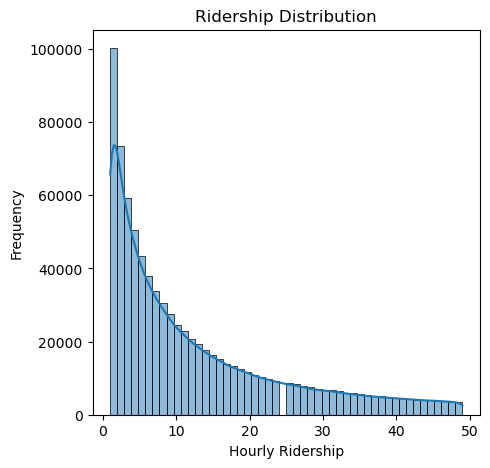

In [103]:
# data exploring
plt.figure(figsize=(5,5))
sns.histplot(df['ridership'], bins=50, kde=True)
plt.title("Ridership Distribution")
plt.xlabel("Hourly Ridership")
plt.ylabel("Frequency")
plt.show()

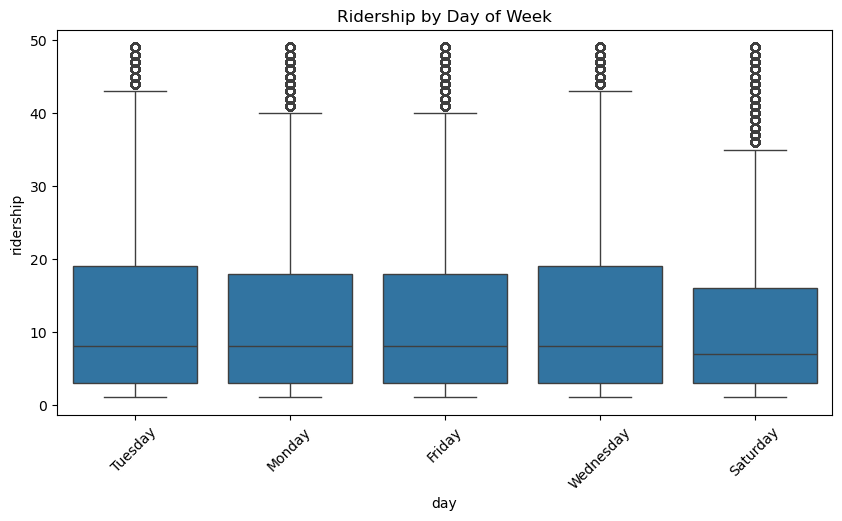

In [ ]:
df['day'] = df['transit_timestamp'].dt.day_name()
plt.figure(figsize=(10,5))
sns.boxplot(x="day", y="ridership", data=df)
plt.title("Ridership by Day of Week")
plt.xticks(rotation=45)
plt.show()
# outliers are weird here. should I be cutting out >50 or no. maybe filter by just metro